# 09 scenarios slope ramp — 勾配・上り下り・ランプ

**対象:** お客様（MPC 設計経験者）との **理論・数式・パラメータ** ディスカッション  
**Part 3/4** — Scenario 11–15

各シナリオは **路面 · 速度 · 勾配 · 実装** を結びつけています。  
理論の前提: [00_theory_grf_mpc_wbc.ipynb](./00_theory_grf_mpc_wbc.ipynb)  
QA 索引: [11_qa_discussion_master.ipynb](./11_qa_discussion_master.ipynb)

```bash
python scripts/scenario_labs.py --list
python scripts/scenario_labs.py --scenario sc11_bumpy_uphill_gravity
```


In [1]:
import sys
from pathlib import Path

# mpc_dog ルートを sys.path に追加
ROOT = Path.cwd()
for p in [ROOT, *ROOT.parents]:
    if (p / "scripts" / "pympc_lab.py").exists():
        ROOT = p
        break
sys.path.insert(0, str(ROOT / "scripts"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pympc_lab import (
    TUNING_GUIDE,
    apply_preset,
    compare_runs,
    load_param_study,
    load_preset_yaml,
    plot_friction_cone,
    run_flat_sim,
    run_speed_terrain_sim,
    run_speed_terrain_sim_resilient,
)

from tuning_labs import (
    TUNING_LABS,
    list_labs,
    run_lab,
    run_lab_pair,
    plot_speed_trial_journey,
    plot_param_study_mu,
    load_cached_lab_results,
)

%matplotlib inline
plt.rcParams["figure.figsize"] = (9, 4)
print(f"repo: {ROOT}")

from scenario_labs import (
    SCENARIO_LABS,
    compare_preset_table,
    run_scenario,
    run_scenario_pair,
    scenario_table,
)


repo: /home/takuya/work/mpc_dog


### 勾配・凸凹（Session 4）

Markdown の `![](../assets/...)` だけでは IDE 内で見えないことがあります。下のセルで **GIF を直接表示** します。

--- s04_flat ---
  scene: bumpy_flat
  final_x_m: 20.0
  final_dist_m: 20.0
  gif_playback_s: 10.0
  falls: 17


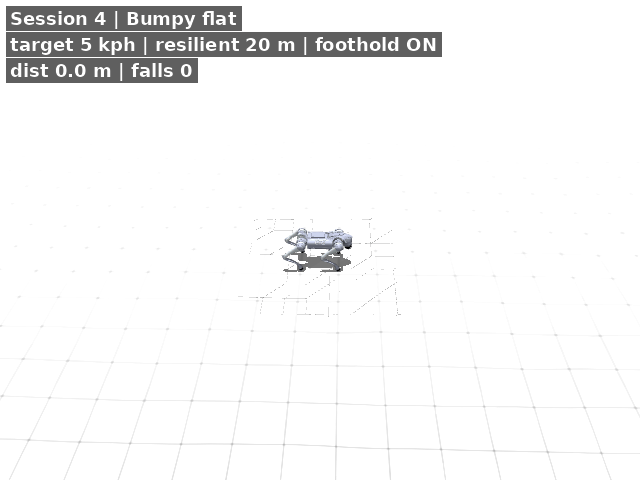

--- s04_uphill ---
  scene: bumpy_uphill
  final_x_m: 20.001
  final_dist_m: 20.001
  gif_playback_s: 10.0
  falls: 22


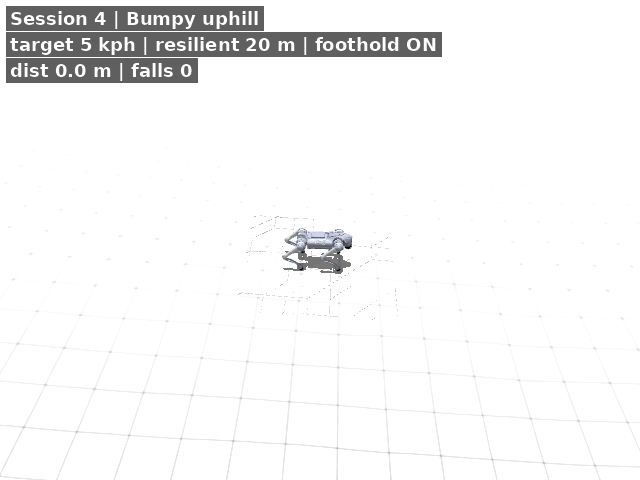

--- s04_downhill ---
  scene: bumpy_downhill
  final_x_m: 20.0
  final_dist_m: 20.0
  gif_playback_s: 10.0
  falls: 23


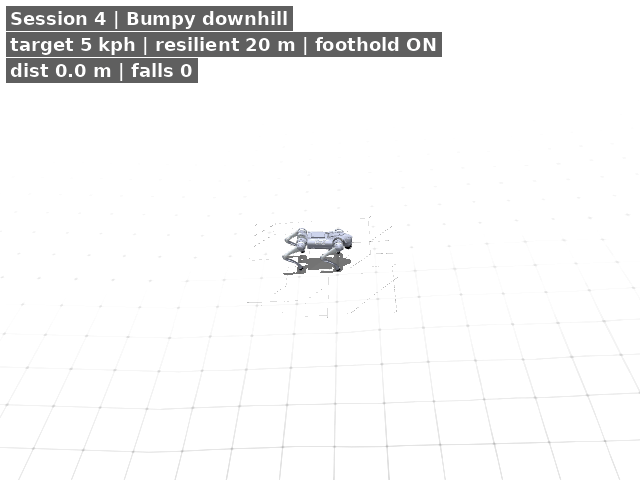

In [2]:
from pathlib import Path
import sys
import json
from IPython.display import Image, display

ROOT = Path.cwd()
for p in [ROOT, *ROOT.parents]:
    if (p / "scripts" / "pympc_lab.py").exists():
        ROOT = p
        break

def show_demo_gifs(tags):
    for tag in tags:
        gif = ROOT / f"docs/pympc_2day/assets/demo_{tag}.gif"
        meta_path = ROOT / f"docs/pympc_2day/assets/demo_{tag}.meta.json"
        print(f"--- {tag} ---")
        if meta_path.is_file():
            m = json.loads(meta_path.read_text())
            for k in ("scene", "final_x_m", "final_dist_m", "gif_playback_s", "falls"):
                if m.get(k) is not None:
                    print(f"  {k}: {m[k]}")
        if gif.is_file():
            display(Image(filename=str(gif)))
        else:
            print("  MISSING:", gif)

show_demo_gifs(["s04_flat", "s04_uphill", "s04_downhill"])


## Scenario 11 — 凸凹上り坂 — 重力成分と pitch

| 項目 | 内容 |
|------|------|
| **ID** | `sc11_bumpy_uphill_gravity` |
| **分類** | slope / advanced |
| **路面** | bumpy_uphill（pitch +0.08 rad） |
| **速度** | 5.0 kph |
| **勾配** | uphill +0.08 rad |
| **preset** | `session04_bumpy_uphill` |

### シナリオ

上りでは $mg\sin\theta$ 分の追加 $F_x$ が必要。μ も freq も平坦より保守。

### 理論（Layer 2–3）

世界系 x 方向: $m a_x = \sum F_{ix} - mg\sin\theta$（近似）。

$$F_{ix}^{req} \approx m a_x + mg\sin\theta, \quad \theta \approx +0.08 \text{ rad}$$

### パラメータ焦点

| `mu` | 0.42→0.38 | `step_freq` | 1.20→1.10 | `speed_ramp_s` | 18→20 |

**実装:** `workshop_terrain.BUMPY_SCENES['bumpy_uphill']` pitch=+0.08

### ノウハウ

上り: μ↓ freq↓ ramp↑ ref_z やや↑。

### 議論用 Q&A

Q: pitch を MPC に入れている？
A: SRB+地形推定経由。明示 slope 項は sim 側重力投影。


In [3]:
# resilient 20 m は数分かかる → 勝者 JSON を表示（GIF は Part 冒頭）
from pympc_lab import load_speed_winners

winners = load_speed_winners()
if "bumpy_uphill" in winners:
    w = winners["bumpy_uphill"]
    print("Winner params:", {k: w[k] for k in ("mu", "step_freq", "duty_factor", "speed_ramp_s") if k in w})
    print("Result:", w["result"])
else:
    print("No cached winner for bumpy_uphill")
print("Full sim: python scripts/scenario_labs.py --scenario sc11_bumpy_uphill_gravity")


Winner params: {'mu': 0.38, 'step_freq': 1.1, 'duty_factor': 0.78, 'speed_ramp_s': 20.0}
Result: {'mode': 'resilient', 'scene': 'bumpy_uphill', 'kph': 5.0, 'distance_m': 20.00156034872587, 'mean_kph': 1.0571338822476009, 'success': True, 'falls': 16}
Full sim: python scripts/scenario_labs.py --scenario sc11_bumpy_uphill_gravity


## Scenario 12 — 凸凹下り坂 — 最難（制動・支持）

| 項目 | 内容 |
|------|------|
| **ID** | `sc12_bumpy_downhill_brake` |
| **分類** | slope / expert |
| **路面** | bumpy_downhill（pitch -0.08 rad） |
| **速度** | 5.0 kph |
| **勾配** | downhill -0.08 rad |
| **preset** | `session04_bumpy_downhill` |

### シナリオ

下りは加速しやすく、duty=0.82, μ=0.35, ramp=22 s まで保守化が必要。

### 理論（Layer 2–3）

下り: $mg\sin|\theta|$ が加速方向。制動 $F_{ix}<0$ も摩擦円錐内で。

$$m a_x = \sum F_{ix} + mg\sin\theta, \quad \theta < 0 \text{（下り）}$$

### パラメータ焦点

| `duty_factor` | 0.76→0.82 | `mu` | 0.42→0.35 | `speed_ramp_s` | 22 |

**実装:** preset: `session04_bumpy_downhill.yaml`

### ノウハウ

下り最難。duty 最大級・μ 最小級・ramp 最長。

### 議論用 Q&A

Q: 下りで freq を上げて速く降りたい？
A: 支持不足で転倒増。duty↑ freq↓ が先。


In [4]:
# resilient 20 m は数分かかる → 勝者 JSON を表示（GIF は Part 冒頭）
from pympc_lab import load_speed_winners

winners = load_speed_winners()
if "bumpy_downhill" in winners:
    w = winners["bumpy_downhill"]
    print("Winner params:", {k: w[k] for k in ("mu", "step_freq", "duty_factor", "speed_ramp_s") if k in w})
    print("Result:", w["result"])
else:
    print("No cached winner for bumpy_downhill")
print("Full sim: python scripts/scenario_labs.py --scenario sc12_bumpy_downhill_brake")


Winner params: {'mu': 0.35, 'step_freq': 1.05, 'duty_factor': 0.82, 'speed_ramp_s': 22.0}
Result: {'mode': 'resilient', 'scene': 'bumpy_downhill', 'kph': 5.0, 'distance_m': 20.000048377677235, 'mean_kph': 0.47261575224254304, 'success': True, 'falls': 24}
Full sim: python scripts/scenario_labs.py --scenario sc12_bumpy_downhill_brake


## Scenario 13 — 上りで下り preset — パラメータ持ち込み失敗（反対）

| 項目 | 内容 |
|------|------|
| **ID** | `sc13_uphill_wrong_preset` |
| **分類** | transition / advanced |
| **路面** | bumpy_uphill |
| **速度** | 5.0 kph |
| **勾配** | uphill（下り用 μ,duty 適用） |
| **preset** | `session04_speed_bumpy_base` |

### シナリオ

下り坂用の μ=0.35, duty=0.82 を上りに適用 → 加速不足・停滞（反対方向の誤適用）。

### 理論（Layer 2–3）

地形ごとに $\theta$ 符号が変わり、必要な $F_{ix}$ 分布も変化。preset は分離保存。

$$\text{uphill: } F_{ix}>0 \text{ 必要}, \quad \text{downhill preset: 過制動}$$

### パラメータ焦点

| 誤 | session04_bumpy_downhill の μ,duty | 正 | session04_bumpy_uphill |

**実装:** compare_presets: `session04_bumpy_downhill` vs `session04_bumpy_uphill`

### ノウハウ

YAML を地形別に。上り→下り切替時は全パラメータを見直し。

### 議論用 Q&A

Q: 上りから下りへ連続走行は？
A: 本 sim は scene 固定。実機は scene 検出+gain scheduling が必要。


backup: /home/takuya/work/mpc_dog/logs/pympc_sessions/session04_speed_bumpy_base/config.py.bak.20260818T222231Z
applied: session04_speed_bumpy_base -> /home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/config.py
notes: Use scripts/run_speed_terrain_benchmark.py to tune per-terrain scene + speed.
Custom scenes: bumpy_flat, bumpy_uphill, bumpy_downhill (workshop_terrain.py).


backup: /home/takuya/work/mpc_dog/logs/pympc_sessions/session04_speed_bumpy_base/config.py.bak.20260818T222231Z
applied: session04_speed_bumpy_base -> /home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/config.py
notes: Use scripts/run_speed_terrain_benchmark.py to tune per-terrain scene + speed.
Custom scenes: bumpy_flat, bumpy_uphill, bumpy_downhill (workshop_terrain.py).


/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


field AcadosOcpDims.N has been migrated to AcadosOcpOptions.N_horizon. setting AcadosOcpOptions.N_horizon = N. For future comppatibility, please use AcadosOcpOptions.N_horizon directly.
External functions generated in 89.752 ms.


Templated solver code generated in 1223.226 ms.
rm -f libacados_ocp_solver_ocp_centroidal_model_2bace23d.so
rm -f centroidal_model_constraints/centroidal_model_constr_h_0_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_0_fun.o centroidal_model_constraints/centroidal_model_constr_h_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_fun.o acados_solver_ocp_centroidal_model_2bace23d.o
cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_constraints/centroidal_model_constr_h_0_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_0_fun_jac_uxt_zt.c
cc -fPIC -std=c99 

...

cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_model/centroidal_model_expl_ode_fun.o centroidal_model_model/centroidal_model_expl_ode_fun.c
cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_model/centroidal_model_expl_vde_forw.o centroidal_model_model/cen

cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_model/centroidal_model_expl_vde_adj.o centroidal_model_model/centroidal_model_expl_vde_adj.c
cc -shared centroidal_model_constraints/centroidal_model_constr_h_0_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_0_fun.o centroidal_model_constraints/centroidal_model_constr_h_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_fun.o acados_solver_ocp_centroidal_model_2bace23d.o centroidal_model_model/centroidal_model_expl_ode_fun.o centroidal_model_model/centroidal_model_expl_vde_forw.o centroidal_model_model/centroidal_model_expl_vde

Build completed in 4660.296 ms.
acados was compiled without OpenMP.


/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


/home/takuya/work/mpc_dog/scripts/pympc_lab.py:596: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/home/takuya/work/mpc_dog/scripts/pympc_lab.py:596: UserWarning: Glyph 12426 (\N{HIRAGANA LETTER RI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/home/takuya/work/mpc_dog/scripts/pympc_lab.py:596: UserWarning: Glyph 12391 (\N{HIRAGANA LETTER DE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/home/takuya/work/mpc_dog/scripts/pympc_lab.py:596: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/home/takuya/work/mpc_dog/scripts/pympc_lab.py:596: UserWarning: Glyph 12497 (\N{KATAKANA LETTER PA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/home/takuya/work/mpc_dog/scripts/pympc_lab.py:596: UserWarning: Glyph 12521 (\N{KATAKANA LETTER RA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/home/takuya/work/mpc_dog/scripts/pympc_la

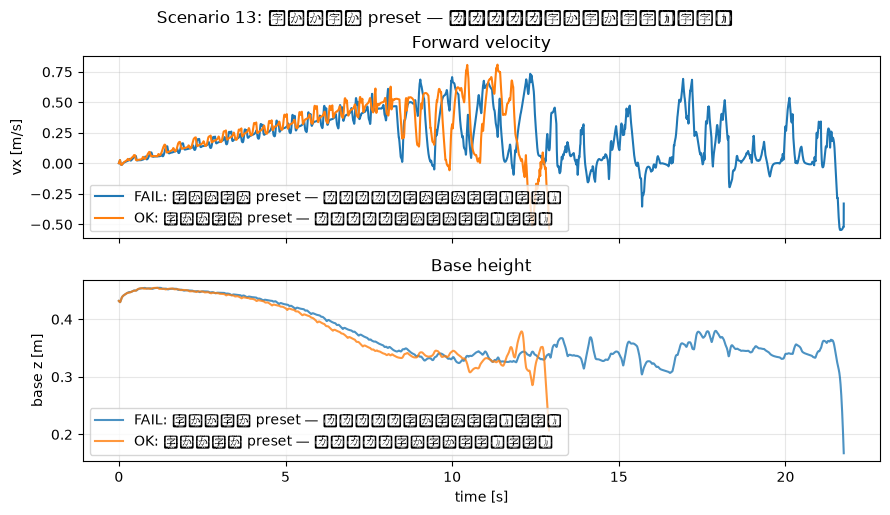

In [5]:
from scenario_labs import run_scenario_pair
from pympc_lab import compare_runs

pair = run_scenario_pair("sc13_uphill_wrong_preset")
fig = compare_runs(pair)
plt.suptitle("Scenario 13: 上りで下り preset — パラメータ持ち込み失敗（反対）", y=1.02)
plt.show()


## Scenario 14 — 下り duty 不足 — 支持時間が命

| 項目 | 内容 |
|------|------|
| **ID** | `sc14_downhill_duty_low` |
| **分類** | slope / expert |
| **路面** | bumpy_downhill |
| **速度** | 5.0 kph |
| **勾配** | downhill |
| **preset** | `session04_bumpy_downhill` |

### シナリオ

duty=0.70 では下り+凸凹で支持脚が足りず連続転倒。

### 理論（Layer 2–3）

duty↑ → $T_{stance}$↑ → 1 足あたり $F_{iz}$ 配分時間↑。

$$T_{stance} = duty / f_{step}, \quad F_{iz,i} \approx \frac{mg}{N_{stance}}$$

### パラメータ焦点

| `duty_factor` | 0.70 → 0.82 | 下り必須 |

**実装:** duty_factor を単独で A/B

### ノウハウ

下りで duty<0.78 は危険域。0.82 が S4 勝者値。

### 議論用 Q&A

Q: duty と freq のどちらが効く？
A: 下りは duty 優先。freq↓は MPC 解の時間的余裕。


In [6]:
# resilient 20 m は数分かかる → 勝者 JSON を表示（GIF は Part 冒頭）
from pympc_lab import load_speed_winners

winners = load_speed_winners()
if "bumpy_downhill" in winners:
    w = winners["bumpy_downhill"]
    print("Winner params:", {k: w[k] for k in ("mu", "step_freq", "duty_factor", "speed_ramp_s") if k in w})
    print("Result:", w["result"])
else:
    print("No cached winner for bumpy_downhill")
print("Full sim: python scripts/scenario_labs.py --scenario sc14_downhill_duty_low")


Winner params: {'mu': 0.35, 'step_freq': 1.05, 'duty_factor': 0.82, 'speed_ramp_s': 22.0}
Result: {'mode': 'resilient', 'scene': 'bumpy_downhill', 'kph': 5.0, 'distance_m': 20.000048377677235, 'mean_kph': 0.47261575224254304, 'success': True, 'falls': 24}
Full sim: python scripts/scenario_labs.py --scenario sc14_downhill_duty_low


## Scenario 15 — speed_ramp — 指令 $v^{ref}(t)$ の立ち上がり

| 項目 | 内容 |
|------|------|
| **ID** | `sc15_ramp_short_vs_long` |
| **分類** | speed / advanced |
| **路面** | bumpy_flat |
| **速度** | 5.0 kph |
| **勾配** | flat + 凸凹 |
| **preset** | `session04_speed_bumpy_base` |

### シナリオ

ramp=8 s では GRF 要求が急峻。18 s で mean_kph は下がるが距離到達。

### 理論（Layer 2–3）

Layer 1/指令: $v^{ref}(t)=v_t\min(t/T_r,1)$。急峻 → $|F_{ix}|$ スパイク。

$$\left|\frac{dv^{ref}}{dt}\right| \downarrow \Rightarrow \left|\sum F_{ix}\right| \text{ のピーク} \downarrow$$

### パラメータ焦点

| `speed_ramp_s` | 8 → 18 | 指令ランプ |

**実装:** `run_speed_terrain_sim` 内 `env._ref_base_lin_vel_H` を ramp

### ノウハウ

転倒→まず ramp↑。次に μ↓ freq↓。

### 議論用 Q&A

Q: ramp を無限に長くすれば良い？
A: 実用距離・時間制約あり。20 m / 5 kph なら 18–22 s が目安。


backup: /home/takuya/work/mpc_dog/logs/pympc_sessions/session04_speed_bumpy_base/config.py.bak.20260818T222334Z
applied: session04_speed_bumpy_base -> /home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/config.py
notes: Use scripts/run_speed_terrain_benchmark.py to tune per-terrain scene + speed.
Custom scenes: bumpy_flat, bumpy_uphill, bumpy_downhill (workshop_terrain.py).
backup: /home/takuya/work/mpc_dog/logs/pympc_sessions/session04_speed_bumpy_base/config.py.bak.20260818T222334Z
applied: session04_speed_bumpy_base -> /home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/config.py
notes: Use scripts/run_speed_terrain_benchmark.py to tune per-terrain scene + speed.
Custom scenes: bumpy_flat, bumpy_uphill, bumpy_downhill (workshop_terrain.py).
field AcadosOcpDims.N has been migrated to AcadosOcpOptions.N_horizon. setting AcadosOcpOptions.N_horizon = N. For future comppatibility, please use AcadosOcpOptions.N_horizon directly.


External functions generated in 84.137 ms.


Templated solver code generated in 1223.912 ms.
rm -f libacados_ocp_solver_ocp_centroidal_model_2bace23d.so
rm -f centroidal_model_constraints/centroidal_model_constr_h_0_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_0_fun.o centroidal_model_constraints/centroidal_model_constr_h_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_fun.o acados_solver_ocp_centroidal_model_2bace23d.o
cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_constraints/centroidal_model_constr_h_0_fun_jac_uxt_zt.o centroidal_model_constraints/centroidal_model_constr_h_0_fun_jac_uxt_zt.c
cc -fPIC -std=c99 

cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o acados_solver_ocp_centroidal_model_2bace23d.o acados_solver_ocp_centroidal_model_2bace23d.c


cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_model/centroidal_model_expl_ode_fun.o centroidal_model_model/centroidal_model_expl_ode_fun.c
cc -fPIC -std=c99   -O2 -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/acados -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/blasfeo/include -I/home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/acados/include/hpipm/include  -c -o centroidal_model_model/centroidal_model_expl_vde_forw.o centroidal_model_model/cen

...

Font 'default' does not have a glyph for '\u7acb' [U+7acb], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u3061' [U+3061], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u4e0a' [U+4e0a], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u304c' [U+304c], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u308a' [U+308a], substituting with a dummy symbol.


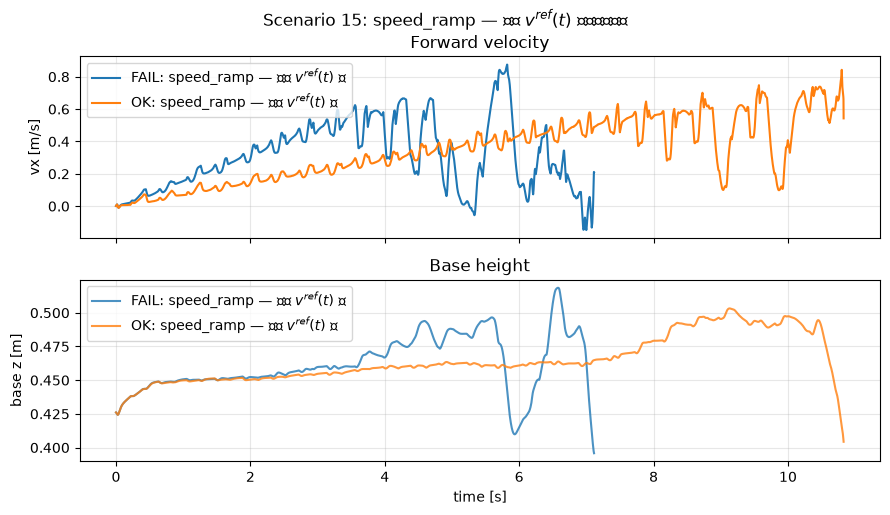

In [7]:
from scenario_labs import run_scenario_pair
from pympc_lab import compare_runs

pair = run_scenario_pair("sc15_ramp_short_vs_long")
fig = compare_runs(pair)
plt.suptitle("Scenario 15: speed_ramp — 指令 $v^{ref}(t)$ の立ち上がり", y=1.02)
plt.show()


---

## Part 3 チェックリスト

- [ ] Scenario 11–15 それぞれ **数式 → パラメータ → 結果** を説明できる  
- [ ] fail / OK の差が **摩擦円錐 · gait · 指令 ramp** のどれか特定できる  
- [ ] `configs/pympc_presets/` の YAML と対応づけられる  

**次:** [10_scenarios_transition_limits.ipynb](./10_scenarios_transition_limits.ipynb)
